Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 

Importing dataset

In [2]:
train = pd.read_csv('/Users/kshitijmr13/Downloads/Rossmann/dataset/train.csv')
test = pd.read_csv('/Users/kshitijmr13/Downloads/Rossmann/dataset/test.csv')
store = pd.read_csv('/Users/kshitijmr13/Downloads/Rossmann/dataset/store.csv')
sample_submission = pd.read_csv('/Users/kshitijmr13/Downloads/Rossmann/dataset/sample_submission.csv')

/var/folders/f2/80jj55nd7tdfwgrs2vrdzq1c0000gn/T/ipykernel_25596/506746960.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/Users/kshitijmr13/Downloads/Rossmann/dataset/train.csv')


In [3]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Merging train with store


In [6]:
train = train.merge(store, on='Store', how='left')

In [7]:
train = train.sort_values("Date")

In [8]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"
1016473,379,2,2013-01-01,0,0,0,0,a,1,d,a,6630.0,NaN,NaN,0,NaN,NaN,NaN
1016472,378,2,2013-01-01,0,0,0,0,a,1,a,c,2140.0,8.0,2012.0,0,NaN,NaN,NaN
1016471,377,2,2013-01-01,0,0,0,0,a,1,a,c,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov"
1016470,376,2,2013-01-01,0,0,0,0,a,1,a,a,160.0,8.0,2012.0,0,NaN,NaN,NaN


------------------------------------------------------------------------------Data Cleaning--------------------------------------------------------------------------------

Checking null values

In [9]:
train.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

Filling null values

In [10]:
train['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
train['CompetitionOpenSinceYear'].fillna(0, inplace=True)
train['Promo2SinceWeek'].fillna(0, inplace=True)
train['Promo2SinceYear'].fillna(0, inplace=True)
train['PromoInterval'].fillna(0, inplace=True)

median_competition_distance = train['CompetitionDistance'].median()
train['CompetitionDistance'].fillna(median_competition_distance, inplace=True)

/var/folders/f2/80jj55nd7tdfwgrs2vrdzq1c0000gn/T/ipykernel_25596/2632969630.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
/var/folders/f2/80jj55nd7tdfwgrs2vrdzq1c0000gn/T/ipykernel_25596/2632969630.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

Checking null values

In [11]:
train.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

Checking Duplicates

In [12]:
train.duplicated().sum()

0

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017209 entries, 1017208 to 0
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  1017209 non-null  float64
 13  CompetitionOpenSi

Checking outliers

In [14]:
q1 = train['Sales'].quantile(0.25)
q3 = train['Sales'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = train[(train['Sales'] < lower) | (train['Sales'] > upper)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 26694


Changing Date data type to datetime

In [15]:
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017209 entries, 1017208 to 0
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1017209 non-nul

Separate data for Time-Series Model

In [17]:
train_prophet = train.copy()

Separating date into year, month, day, and week of the year

In [18]:
train = train.sort_values(by=['Store', 'Date'])

In [19]:
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Day'] = train['Date'].dt.day
train['Weekday'] = train['Date'].dt.weekday
train['Week'] = train['Date'].dt.isocalendar().week

train.drop(['Date'], axis=1, inplace=True)

In [20]:
train.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Weekday,Week
1016095,1,2,0,0,0,0,a,1,c,a,...,2008.0,0,0.0,0.0,0,2013,1,1,1,1
1014980,1,3,5530,668,1,0,0,1,c,a,...,2008.0,0,0.0,0.0,0,2013,1,2,2,1
1013865,1,4,4327,578,1,0,0,1,c,a,...,2008.0,0,0.0,0.0,0,2013,1,3,3,1
1012750,1,5,4486,619,1,0,0,1,c,a,...,2008.0,0,0.0,0.0,0,2013,1,4,4,1
1011635,1,6,4997,635,1,0,0,1,c,a,...,2008.0,0,0.0,0.0,0,2013,1,5,5,1


Marking Weekends

In [21]:
train['Weekend'] = train['Weekday'].isin([5, 6]).astype(int)

Calculating different lag values

In [22]:
lags = [1, 7, 14, 30, 60, 90]
for lag in lags:
    train[f'Lag_{lag}'] = train.groupby('Store')['Sales'].shift(lag)

Calculating Rolling Average

In [23]:
window_sizes = [7, 14, 30, 60, 90]
for window in window_sizes:
    train[f'Rolling_Average_{window}'] = train.groupby('Store')['Sales'].shift(1).rolling(window).mean()

Calculating Monthly Average

In [24]:
train['Monthly_Average'] = train.groupby(['Store', 'Month'])['Sales'].transform('mean')

Calculating Store Average Demand

In [25]:
train['Store_Average_Demand'] = train.groupby('Store')['Sales'].transform('mean')

In [26]:
train.isnull().sum()

Store                             0
DayOfWeek                         0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth         0
CompetitionOpenSinceYear          0
Promo2                            0
Promo2SinceWeek                   0
Promo2SinceYear                   0
PromoInterval                     0
Year                              0
Month                             0
Day                               0
Weekday                           0
Week                              0
Weekend                           0
Lag_1                          1115
Lag_7                          7805
Lag_14                        15610
Lag_30                        33450
Lag_60                      

Filling final null values 

In [27]:
train.fillna(0, inplace=True)

In [28]:
train.shape

(1017209, 36)

Splitting into train and validation

In [29]:
x = train.drop(['Sales', 'Customers'], axis=1)
y = train['Sales']

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Encoding and Standardization for Linear Regression

In [31]:
x_train_lr = x_train.copy()
x_test_lr = x_test.copy()

In [32]:
#OHE
categorical_features = ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']
x_train_lr = pd.get_dummies(x_train_lr, columns=categorical_features, drop_first=True)
x_test_lr = pd.get_dummies(x_test_lr, columns=categorical_features, drop_first=True)
x_train_lr, x_test_lr = x_train_lr.align(x_test_lr, join='left', axis=1, fill_value=0)

In [33]:
#Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_features = x_train_lr.select_dtypes(include=['int64', 'float64']).columns
x_train_lr[numeric_features] = scaler.fit_transform(x_train_lr[numeric_features])
x_test_lr[numeric_features] = scaler.transform(x_test_lr[numeric_features])

Encoding for Decision Tree

In [34]:
x_train_dt = x_train.copy()
x_test_dt = x_test.copy()

In [ ]:
#OHE 
x_train_dt = pd.get_dummies(x_train_dt, columns=categorical_features, drop_first=True)
x_test_dt = pd.get_dummies(x_test_dt, columns=categorical_features, drop_first=True)
x_train_dt, x_test_dt = x_train_dt.align(x_test_dt, join='left', axis=1, fill_value=0)

Encoding for CatBoost

In [36]:
x_train_cb = pd.get_dummies(x_train, columns=categorical_features, drop_first=True)
x_test_cb = pd.get_dummies(x_test, columns=categorical_features, drop_first=True)
x_train_cb, x_test_cb = x_train_cb.align(x_test_cb, join='left', axis=1, fill_value=0)

Plots

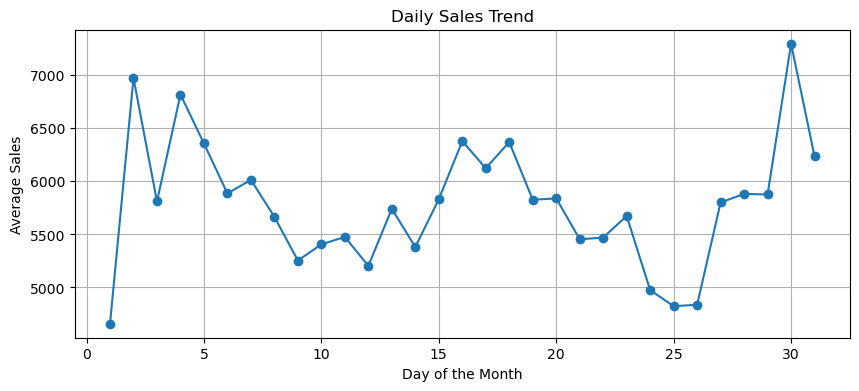

In [37]:
# Daily Sales Trend
daily_sales = train.groupby('Day')['Sales'].mean()
plt.figure(figsize=(10, 4))
plt.plot(daily_sales.index, daily_sales.values, marker='o')
plt.title('Daily Sales Trend')
plt.xlabel('Day of the Month')
plt.ylabel('Average Sales')
plt.grid()
plt.show()

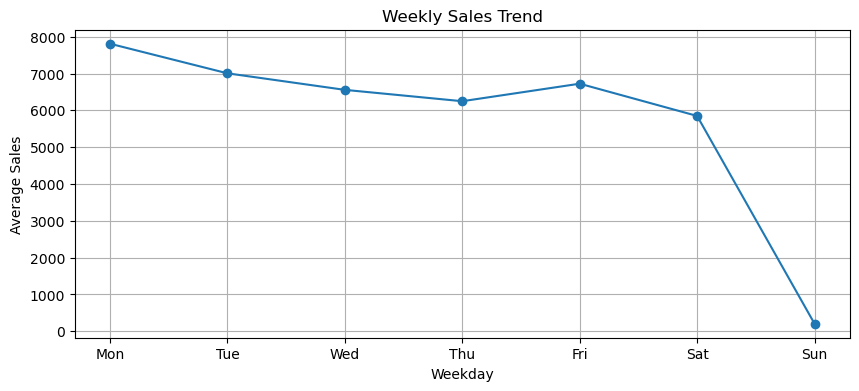

In [38]:
# Weekly Sales Trend
weekday_sales = train.groupby('Weekday')['Sales'].mean()
plt.figure(figsize=(10, 4))
plt.plot(weekday_sales.index, weekday_sales.values, marker='o')
plt.xticks([0,1,2,3,4,5,6], ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title('Weekly Sales Trend')
plt.xlabel('Weekday')
plt.ylabel('Average Sales')
plt.grid()
plt.show()

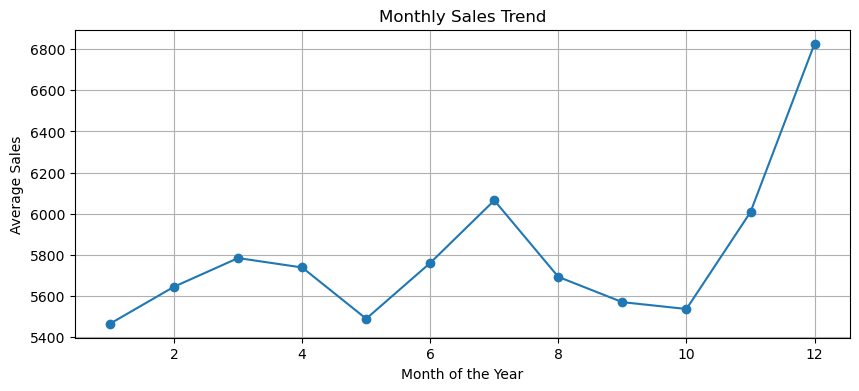

In [39]:
# Monthly Sales Trend
monthly_sales = train.groupby('Month')['Sales'].mean()
plt.figure(figsize=(10, 4))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month of the Year')
plt.ylabel('Average Sales')
plt.grid()
plt.show()

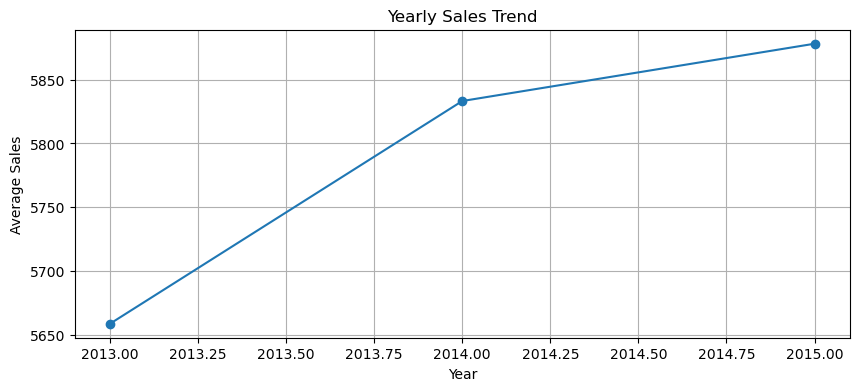

In [40]:
# Yearly Sales Trend
yearly_sales = train.groupby('Year')['Sales'].mean()
plt.figure(figsize=(10, 4))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.grid()
plt.show()

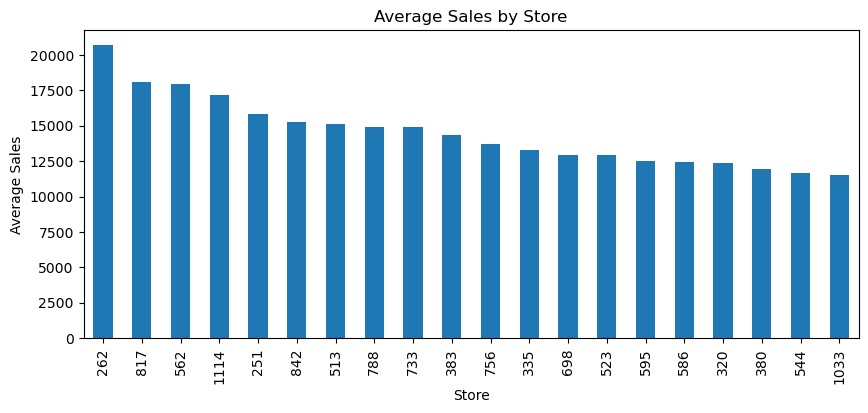

In [41]:
# Average Sales by Store
store_sales = train.groupby('Store')['Sales'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 4))
store_sales.plot(kind='bar')
plt.title('Average Sales by Store')
plt.xlabel('Store')
plt.ylabel('Average Sales')
plt.show()

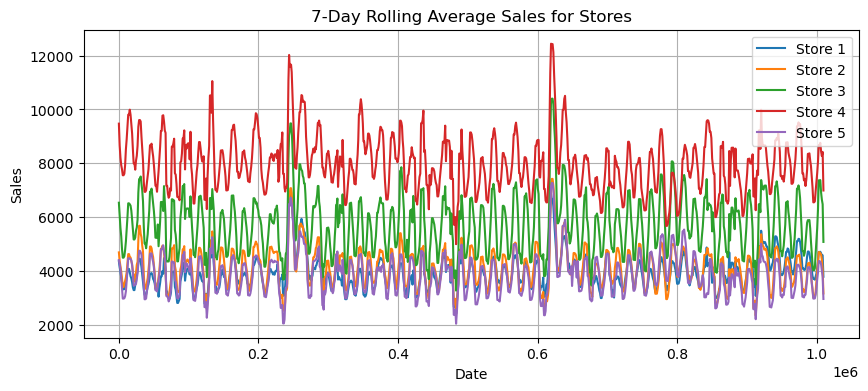

In [ ]:
# 7-Day Rolling Average Sales for Stores
rolling_avg_sales = train.groupby('Store')['Sales'].rolling(window=7).mean()
plt.figure(figsize=(10, 4))
for store in train['Store'].unique()[:5]:
    plt.plot(rolling_avg_sales[store].index, rolling_avg_sales[store].values, label=f'Store {store}')
plt.title('7-Day Rolling Average Sales for Stores')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

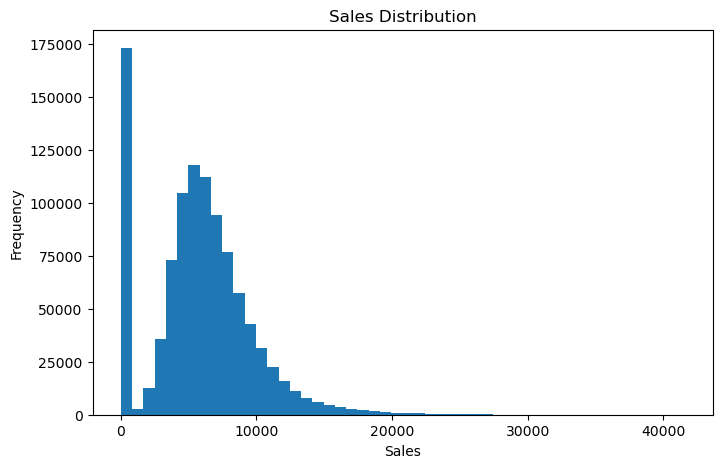

In [43]:
# Sales Distribution
plt.figure(figsize=(8,5))
plt.hist(train['Sales'], bins=50)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

Model Training

1. Linear Regression

In [44]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_lr, y_train)
y_pred_lr = lr.predict(x_test_lr)
score_lr = lr.score(x_test_lr, y_test)
print(f"Linear Regression R^2 Score: {score_lr:.4f}")

Linear Regression R^2 Score: 0.8636


2. Decision Tree Regressor

In [45]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42) 
dt.fit(x_train_dt, y_train)
y_pred_dt = dt.predict(x_test_dt)
score_dt = dt.score(x_test_dt, y_test)
print(f"Decision Tree R^2 Score: {score_dt:.4f}")

Decision Tree R^2 Score: 0.9338


3. CatBoost Regressor

In [46]:
# Catboost
from catboost import CatBoostRegressor
catboost_model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, eval_metric='R2', random_state=42, verbose=100)
catboost_model.fit(x_train_cb, y_train)
y_pred_catboost = catboost_model.predict(x_test_cb)
score_catboost = catboost_model.score(x_test_cb, y_test)
print(f"CatBoost R^2 Score: {score_catboost:.4f}")

0:	learn: 0.1596650	total: 96.5ms	remaining: 1m 36s
100:	learn: 0.9502664	total: 3.28s	remaining: 29.2s
200:	learn: 0.9586524	total: 6.33s	remaining: 25.2s
300:	learn: 0.9622750	total: 9.63s	remaining: 22.4s
400:	learn: 0.9645380	total: 13.2s	remaining: 19.8s
500:	learn: 0.9662155	total: 17s	remaining: 17s
600:	learn: 0.9674916	total: 20.7s	remaining: 13.7s
700:	learn: 0.9684718	total: 24.7s	remaining: 10.5s
800:	learn: 0.9692749	total: 28.9s	remaining: 7.18s
900:	learn: 0.9699754	total: 32.4s	remaining: 3.56s
999:	learn: 0.9705649	total: 36.5s	remaining: 0us
CatBoost R^2 Score: 0.9693


4. Time Series Model

In [47]:
from prophet import Prophet

In [48]:
# Prepare Prophet dataset
x_prophet = train_prophet[
[
'Date',
'Sales',
'Promo',
'Open',
'SchoolHoliday',
'StateHoliday',
'DayOfWeek',
'CompetitionDistance',
'Promo2'
]].copy()

# Convert StateHoliday to binary
x_prophet['StateHoliday'] = (x_prophet['StateHoliday'] != '0').astype(int)

# Rename columns for Prophet
x_prophet = x_prophet.rename(columns={'Date': 'ds', 'Sales': 'y'})

# Sort chronologically
x_prophet = x_prophet.sort_values("ds")

# Chronological split
split = int(len(x_prophet) * 0.8)

x_train_prophet = x_prophet.iloc[:split].copy()
x_test_prophet = x_prophet.iloc[split:].copy()
y_prophet = train_prophet['Sales']

In [ ]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=15,
    holidays_prior_scale=20,
    n_changepoints=100
)

In [50]:
# Add regressors to the Prophet model
regressors = [
    'Promo',
    'Open',
    'SchoolHoliday',
    'StateHoliday',
    'DayOfWeek',
    'CompetitionDistance',
    'Promo2'
]

for reg in regressors:
    model_prophet.add_regressor(reg)


In [ ]:
# Monthly Seasonality
model_prophet.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=10
)

# Quarterly Seasonality
model_prophet.add_seasonality(
    name='quarterly',
    period=91.25,
    fourier_order=8
)

In [52]:
# Fitting the Prophet model
model_prophet.fit(x_train_prophet)

11:27:32 - cmdstanpy - INFO - Chain [1] start processing
11:42:22 - cmdstanpy - INFO - Chain [1] done processing


Model Evaluation

1. Linear Regression

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_pred = lr.predict(x_test_lr)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

Linear Regression
MAE : 1009.1472005073928
RMSE: 1425.3523952650714
R2  : 0.8635976925435863


2. Decision Tree

In [54]:
dt_pred = dt.predict(x_test_dt)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2  :", dt_r2)

Decision Tree
MAE : 617.1846816291621
RMSE: 992.6502437488265
R2  : 0.933843925971825


3. CatBoost

In [55]:
cb_pred = catboost_model.predict(x_test_cb)

cb_mae = mean_absolute_error(y_test, cb_pred)
cb_rmse = np.sqrt(mean_squared_error(y_test, cb_pred))
cb_r2 = r2_score(y_test, cb_pred)
print("CatBoost")
print("MAE :", cb_mae)
print("RMSE:", cb_rmse)
print("R2  :", cb_r2)

CatBoost
MAE : 439.5946701648483
RMSE: 675.9377218731868
R2  : 0.9693245752653792


4. Prophet Model Prediction and Evaluation

In [56]:
forecast = model_prophet.predict(
    x_test_prophet[
        [
            'ds',
            'Promo',
            'Open',
            'SchoolHoliday',
            'StateHoliday',
            'DayOfWeek',
            'CompetitionDistance',
            'Promo2'
        ]
    ]
)

prophet_pred = forecast['yhat']

prophet_mae = mean_absolute_error(
    x_test_prophet['y'],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        x_test_prophet['y'],
        prophet_pred
    )
)

prophet_r2 = r2_score(
    x_test_prophet['y'],
    prophet_pred
)

print("Prophet Results")
print("MAE :", prophet_mae)
print("RMSE:", prophet_rmse)
print("R²  :", prophet_r2)

Prophet Results
MAE : 1933.294218345466
RMSE: 2806.9269420944433
R²  : 0.4723339540397882


Hyperparameter Tuning

1. Decision Tree

In [62]:
# Hyperparameter tuning for Decision Tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

param_grid_dt = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']}

dt = DecisionTreeRegressor(random_state=42)

grid_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_dt.fit(x_train_dt, y_train)
print("Best parameters for Decision Tree:", grid_dt.best_params_)
print("Best RMSE for Decision Tree:", -grid_dt.best_score_)
best_dt = grid_dt.best_estimator_

Best parameters for Decision Tree: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best RMSE for Decision Tree: 841.007817609762


2. CatBoost Regressor

In [63]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

param_grid_cb = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 500, 800],
    'l2_leaf_reg': [0, 1, 3]
}

grid_cb = GridSearchCV(estimator=cat, param_grid=param_grid_cb, cv=5, scoring='neg_root_mean_squared_error', error_score='raise', n_jobs=-1)
grid_cb.fit(x_train_cb, y_train)
print("Best parameters for CatBoost:", grid_cb.best_params_)
print("Best RMSE for CatBoost:", -grid_cb.best_score_)
best_cb = grid_cb.best_estimator_

Best parameters for CatBoost: {'depth': 8, 'iterations': 800, 'l2_leaf_reg': 0, 'learning_rate': 0.1}
Best RMSE for CatBoost: 651.0918636230075


Plots

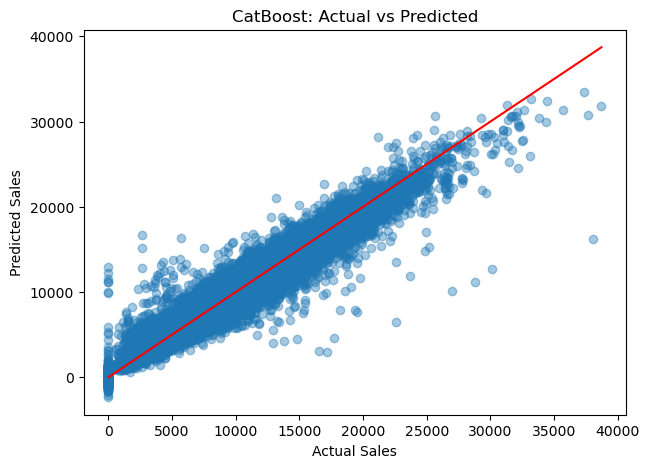

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(7,5))

plt.scatter(y_test, cb_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.title("CatBoost: Actual vs Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()

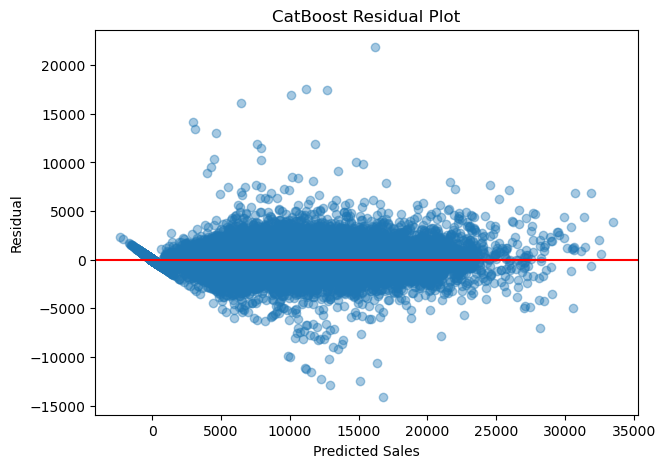

In [60]:
# Residual Plot
cb_residual = y_test - cb_pred

plt.figure(figsize=(7,5))

plt.scatter(
    cb_pred,
    cb_residual,
    alpha=0.4
)

plt.axhline(
    y=0,
    color='red'
)

plt.title("CatBoost Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")

plt.show()

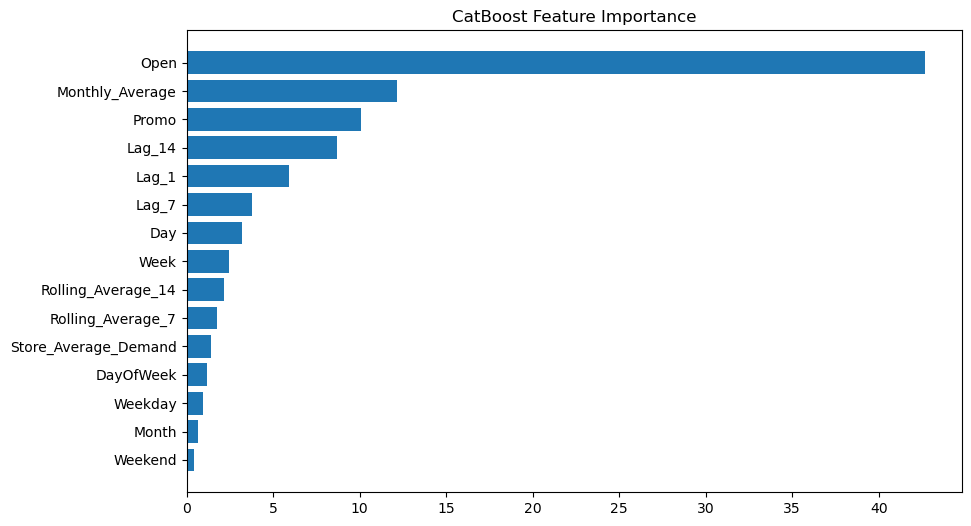

In [61]:
# CatBoost Feature Importance
importance = pd.DataFrame({
    "Feature": x_train_cb.columns,
    "Importance": catboost_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.title("CatBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

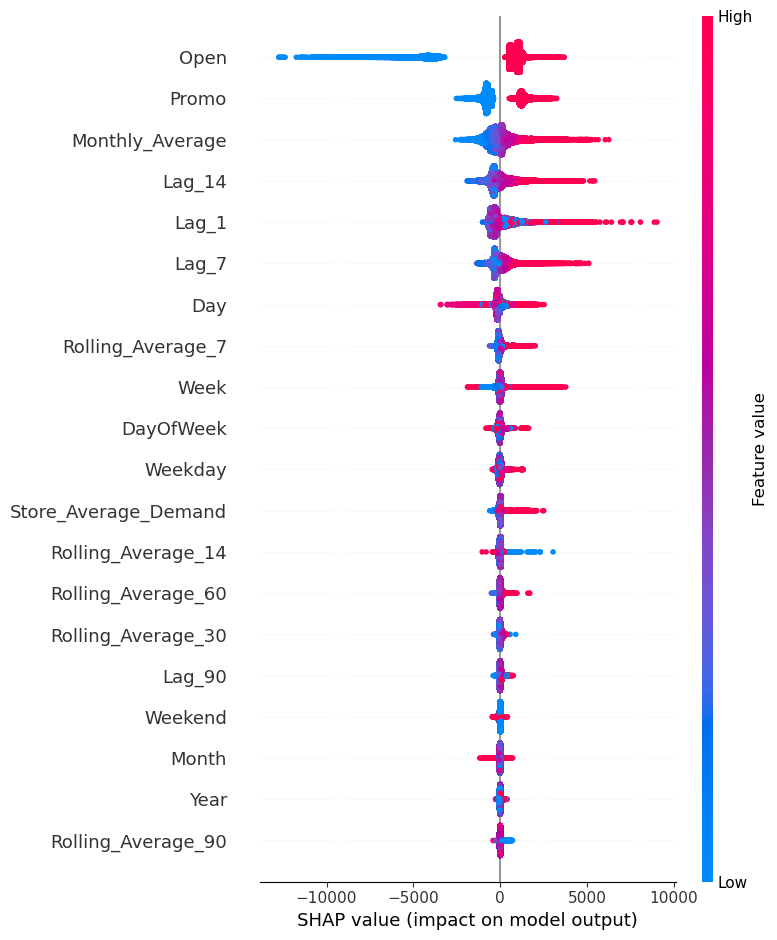

In [62]:
# SHAP Summary Plot
import shap

explainer = shap.TreeExplainer(catboost_model)

shap_values = explainer.shap_values(x_test_cb)

shap.summary_plot(
    shap_values,
    x_test_cb
)

In [124]:
import mlflow
import mlflow.sklearn
import mlflow.prophet

import matplotlib.pyplot as plt
import time
import os

In [127]:
import os
import shutil
import mlflow

tracking_dir = os.path.abspath("rossmann_tracking")

# Remove any previous tracking directory
if os.path.exists(tracking_dir):
    shutil.rmtree(tracking_dir)

os.makedirs(tracking_dir)

mlflow.set_tracking_uri(f"file://{tracking_dir}")

mlflow.set_experiment("Rossmann Sales Forecasting")

2026/07/04 13:12:09 INFO mlflow.tracking.fluent: Experiment with name 'Rossmann Sales Forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///Users/kshitijmr13/Downloads/Rossmann/rossmann_tracking/847585953423134092', creation_time=1783150929860, experiment_id='847585953423134092', last_update_time=1783150929860, lifecycle_stage='active', name='Rossmann Sales Forecasting', tags={}>

In [128]:
start = time.time()

lr.fit(x_train_lr, y_train)

training_time = time.time() - start

lr_pred = lr.predict(x_test_lr)

In [129]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(lr_pred, y_test-lr_pred)

plt.axhline(0,color='red')

plt.title("Linear Regression Residual Plot")

plt.savefig("lr_residual.png")

plt.close()

In [131]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Rossmann Sales Forecasting")

2026/07/04 13:15:18 INFO mlflow.tracking.fluent: Experiment with name 'Rossmann Sales Forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///Users/kshitijmr13/Downloads/Rossmann/mlruns/992719901423730979', creation_time=1783151118840, experiment_id='992719901423730979', last_update_time=1783151118840, lifecycle_stage='active', name='Rossmann Sales Forecasting', tags={}>

In [133]:
with mlflow.start_run(run_name="Linear Regression"):

    mlflow.log_param("Model","Linear Regression")

    mlflow.log_params(lr.get_params())

    mlflow.log_metric("MAE",lr_mae)
    mlflow.log_metric("RMSE",lr_rmse)
    mlflow.log_metric("R2",lr_r2)
    mlflow.log_metric("Training Time",training_time)

    mlflow.log_text(
        "\n".join(x_train_lr.columns),
        "features.txt"
    )

    mlflow.log_artifact("lr_residual.png")

    mlflow.sklearn.log_model(
        sk_model=lr,
        artifact_path="LinearRegression"
    )

2026/07/04 13:15:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [134]:
start=time.time()

dt.fit(x_train_dt,y_train)

training_time=time.time()-start

dt_pred=dt.predict(x_test_dt)

In [135]:
dt_mae=mean_absolute_error(y_test,dt_pred)
dt_rmse=np.sqrt(mean_squared_error(y_test,dt_pred))
dt_r2=r2_score(y_test,dt_pred)

In [136]:
importance=pd.DataFrame({
    "Feature":x_train_dt.columns,
    "Importance":dt.feature_importances_
})

importance=importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.savefig("dt_feature_importance.png")

plt.close()

In [137]:
with mlflow.start_run(run_name="Decision Tree"):

    mlflow.log_param("Model","Decision Tree")

    mlflow.log_params(dt.get_params())

    mlflow.log_metric("MAE",dt_mae)
    mlflow.log_metric("RMSE",dt_rmse)
    mlflow.log_metric("R2",dt_r2)
    mlflow.log_metric("Training Time",training_time)

    mlflow.log_artifact("dt_feature_importance.png")

    mlflow.sklearn.log_model(
        sk_model=dt,
        artifact_path="DecisionTree"
    )

2026/07/04 13:16:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [138]:
start=time.time()

catboost_model.fit(x_train_cb,y_train)

training_time=time.time()-start

cb_pred=catboost_model.predict(x_test_cb)

0:	learn: 0.1596650	total: 86.7ms	remaining: 1m 26s
100:	learn: 0.9502664	total: 3.13s	remaining: 27.9s
200:	learn: 0.9586524	total: 6.62s	remaining: 26.3s
300:	learn: 0.9622750	total: 9.95s	remaining: 23.1s
400:	learn: 0.9645380	total: 13.8s	remaining: 20.7s
500:	learn: 0.9662155	total: 16.7s	remaining: 16.7s
600:	learn: 0.9674916	total: 20.2s	remaining: 13.4s
700:	learn: 0.9684718	total: 23.9s	remaining: 10.2s
800:	learn: 0.9692749	total: 27s	remaining: 6.7s
900:	learn: 0.9699754	total: 30.8s	remaining: 3.39s
999:	learn: 0.9705649	total: 34s	remaining: 0us


In [139]:
cb_mae=mean_absolute_error(y_test,cb_pred)
cb_rmse=np.sqrt(mean_squared_error(y_test,cb_pred))
cb_r2=r2_score(y_test,cb_pred)

In [140]:
importance=pd.DataFrame({
    "Feature":x_train_cb.columns,
    "Importance":catboost_model.feature_importances_
})

importance=importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.savefig("cb_feature_importance.png")

plt.close()

In [141]:
plt.figure(figsize=(8,5))

plt.scatter(cb_pred,y_test-cb_pred)

plt.axhline(0,color='red')

plt.savefig("cb_residual.png")

plt.close()

In [142]:
with mlflow.start_run(run_name="CatBoost"):

    mlflow.log_param("Model","CatBoost")

    mlflow.log_params(catboost_model.get_params())

    mlflow.log_metric("MAE",cb_mae)
    mlflow.log_metric("RMSE",cb_rmse)
    mlflow.log_metric("R2",cb_r2)
    mlflow.log_metric("Training Time",training_time)

    mlflow.log_artifact("cb_feature_importance.png")
    mlflow.log_artifact("cb_residual.png")

    mlflow.sklearn.log_model(
        sk_model=catboost_model,
        artifact_path="CatBoost"
    )

2026/07/04 13:16:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [143]:
plt.figure(figsize=(15,6))

plt.plot(
    x_test_prophet["ds"],
    x_test_prophet["y"],
    label="Actual"
)

plt.plot(
    x_test_prophet["ds"],
    prophet_pred,
    label="Forecast"
)

plt.legend()

plt.savefig("prophet_forecast.png")

plt.close()

In [144]:
rolling=pd.DataFrame({
    "Date":x_test_prophet["ds"],
    "Actual":x_test_prophet["y"],
    "Predicted":prophet_pred
})

rolling["ActualRolling"]=rolling["Actual"].rolling(30).mean()
rolling["PredRolling"]=rolling["Predicted"].rolling(30).mean()

plt.figure(figsize=(15,6))

plt.plot(
    rolling["Date"],
    rolling["ActualRolling"],
    label="Actual"
)

plt.plot(
    rolling["Date"],
    rolling["PredRolling"],
    label="Forecast"
)

plt.legend()

plt.savefig("rolling_forecast.png")

plt.close()

In [145]:
with mlflow.start_run(run_name="Prophet"):

    mlflow.log_param("Model","Prophet")

    mlflow.log_metric("MAE",prophet_mae)
    mlflow.log_metric("RMSE",prophet_rmse)
    mlflow.log_metric("R2",prophet_r2)

    mlflow.log_artifact("prophet_forecast.png")
    mlflow.log_artifact("rolling_forecast.png")

    mlflow.prophet.log_model(
        pr_model=model_prophet,
        artifact_path="Prophet"
    )

2026/07/04 13:17:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [146]:
with mlflow.start_run(run_name="Best Model"):

    mlflow.sklearn.log_model(
        sk_model=catboost_model,
        artifact_path="Rossmann_Best_Model",
        registered_model_name="Rossmann_Best_Model"
    )

2026/07/04 13:18:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'Rossmann_Best_Model'.
Created version '1' of model 'Rossmann_Best_Model'.


In [149]:
with mlflow.start_run(run_name="Best CatBoost Model"):

    mlflow.log_param("Model", "CatBoost")

    mlflow.log_params(catboost_model.get_params())

    mlflow.log_metric("MAE", cb_mae)
    mlflow.log_metric("RMSE", cb_rmse)
    mlflow.log_metric("R2", cb_r2)

    mlflow.log_artifact("cb_feature_importance.png")
    mlflow.log_artifact("cb_residual.png")

    mlflow.sklearn.log_model(
        sk_model=catboost_model,
        artifact_path="Rossmann_Best_Model",
        registered_model_name="Rossmann_Best_Model"
    )

2026/07/04 13:24:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'Rossmann_Best_Model' already exists. Creating a new version of this model...
Created version '2' of model 'Rossmann_Best_Model'.


In [152]:
from mlflow.models import infer_signature

# Example training data
X_sample = x_train_cb.head(5)

# Model predictions
predictions = catboost_model.predict(X_sample)

signature = infer_signature(X_sample, predictions)

mlflow.sklearn.log_model(
    sk_model=catboost_model,
    artifact_path="model",
    signature=signature,
    input_example=X_sample
)

/opt/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/04 13:54:44 WARNING mlflow.models.model: Logging model metadata to the tracking server has failed. The model artifacts have been logged successfully under file:///Users/kshitijmr13/Downloads/Rossmann/mlruns/992719901423730979/b71d849c63

In [154]:
pred = catboost_model.predict(x_test_cb)

signature = infer_signature(x_test_cb, pred)

mlflow.catboost.log_model(
    catboost_model,
    "model",
    signature=signature,
    input_example=x_test_cb.head()
)

/opt/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/04 13:57:08 WARNING mlflow.models.model: Logging model metadata to the tracking server has failed. The model artifacts have been logged successfully under file:///Users/kshitijmr13/Downloads/Rossmann/mlruns/992719901423730979/b71d849c63